In [1]:
import pandas as pd

# 상대 경로 직접 사용 (notebook 위치 기준)
df = pd.read_csv('../../../../../data/ML/preprocessed_office_data.csv')
print(f"데이터 로드 완료: {len(df)} rows")
df.info()

데이터 로드 완료: 351 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   등록번호       351 non-null    object 
 1   중개사무소명     351 non-null    object 
 2   대표자        351 non-null    object 
 3   전화번호       351 non-null    object 
 4   주소         351 non-null    object 
 5   거래완료       351 non-null    object 
 6   등록매물       351 non-null    object 
 7   보증보험시작일    351 non-null    object 
 8   보증보험종료일    351 non-null    object 
 9   등록일        351 non-null    object 
 10  상태구분코드     351 non-null    float64
 11  상태구분명      351 non-null    object 
 12  지역코드       351 non-null    float64
 13  지역명        351 non-null    object 
 14  최종수정일      351 non-null    object 
 15  대표자구분명     351 non-null    object 
 16  총_직원수      351 non-null    int64  
 17  공인중개사수     351 non-null    int64  
 18  중개보조원수     351 non-null    int64  
 19  대표수        351 non-null    int

# 거래 성사율

In [2]:
# 1. 숫자 변환 (예: "51건", "9건" → 51, 9)
def to_int(x):
    if isinstance(x, str):
        return int(x.replace("건", "").strip())
    return x

df["거래완료"] = df["거래완료_숫자"].apply(to_int)
df["등록매물"] = df["등록매물_숫자"].apply(to_int)

# 2. 전체 매물 (거래완료 + 등록매물)
df["전체매물"] = df["거래완료"] + df["등록매물"]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 3. 거래성사율 계산 (0으로 나누기 방지)
df["거래성사율"] = df["거래완료"] / (df["전체매물"] + 1e-6)

print(df[["거래완료", "등록매물", "전체매물", "거래성사율"]].head())


    거래완료  등록매물   전체매물     거래성사율
0  161.0  10.0  171.0  0.941520
1   76.0   5.0   81.0  0.938272
2  403.0  12.0  415.0  0.971084
3  152.0  12.0  164.0  0.926829
4  380.0  14.0  394.0  0.964467


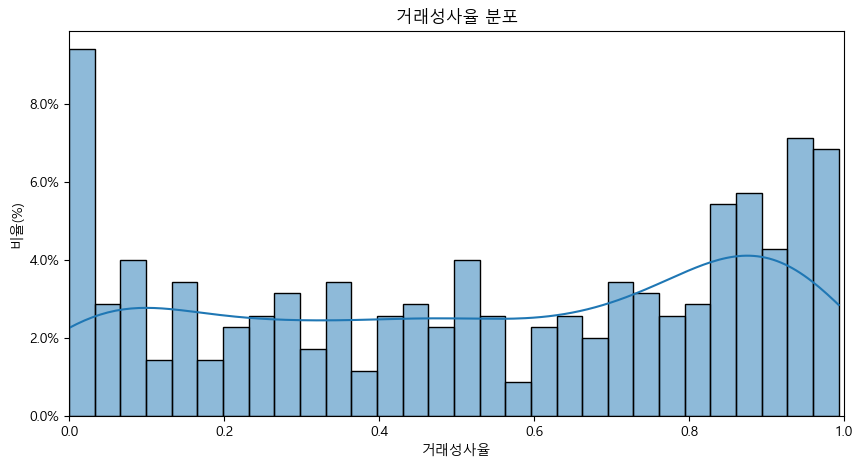

In [4]:
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,5))
sns.histplot(df["거래성사율"], bins=30, kde=True, stat="probability")

plt.xlim(0, 1)
plt.xlabel("거래성사율")
plt.ylabel("비율(%)")
plt.title("거래성사율 분포")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

# 지역별 Z-score
- 지역별 거래 성사율의 평균, 표준편차를 계산

In [5]:
# 지역별 평균과 표준편차 계산
region_mean = df.groupby("지역명")["거래성사율"].transform("mean")
region_std  = df.groupby("지역명")["거래성사율"].transform("std")

# Z-score 생성  
df["지역대비_Z"] = (df["거래성사율"] - region_mean) / (region_std + 1e-6)


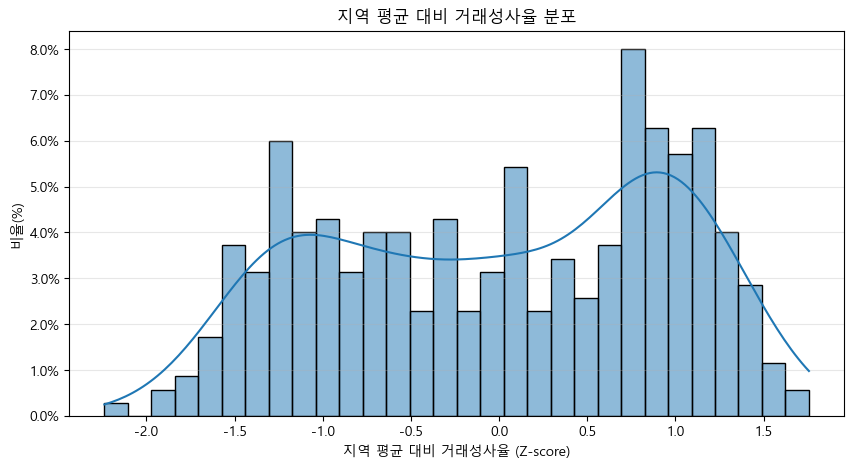

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))

sns.histplot(df["지역대비_Z"], bins=30, kde=True, stat="probability")

plt.xlabel("지역 평균 대비 거래성사율 (Z-score)")
plt.ylabel("비율(%)")
plt.title("지역 평균 대비 거래성사율 분포")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)

plt.show()


#  개인성사율이 지역 평균보다 얼마나 높은지
# -------------------------------------
#  그 지역 성사율이 원래 얼마나 들쭉날쭉한가

## 지역별 평균/표준편차 계산 → 개인별 Z-score 생성 → A/B/C 등급 생성 → 요약표 + 그래프 시각화

### 지역별 평균/표준편차 계산

In [7]:
import pandas as pd
import numpy as np

# -----------------------------
# 1) 지역별 평균 성사율 / 표준편차 계산
# -----------------------------
df["지역평균"] = df.groupby("지역명")["거래성사율"].transform("mean")
df["지역표준편차"] = df.groupby("지역명")["거래성사율"].transform("std")

# -----------------------------
# 2) 개인별 Performance Z-score 생성
# -----------------------------
df["Performance_Zscore"] = (df["거래성사율"] - df["지역평균"]) / (df["지역표준편차"] + 1e-6)

# -----------------------------
# 3) 자격 가중치 적용 (법인 > 공인중개사 > 중개보조원 > 중개인 > 미등록)
# -----------------------------
qualification_map = {
    "법인": 2,
    "공인중개사": 1,
    "중개보조원": 0,
    "중개인": -1,
    "미등록": -2
}
df["대표자구분명"] = df["대표자구분명"].fillna("미등록")
df["자격점수"] = df["대표자구분명"].map(qualification_map).fillna(-2)

# 자격점수 Z-score (Qual_Zscore)
qual_mean = df["자격점수"].mean()
qual_std = df["자격점수"].std() + 1e-6
df["Qual_Zscore"] = (df["자격점수"] - qual_mean) / qual_std

# -----------------------------
# 4) 최종 복합 Z-score (실적 80% + 자격 20%)
# -----------------------------
df["Zscore"] = (df["Performance_Zscore"] * 0.8) + (df["Qual_Zscore"] * 0.2)


In [8]:
# 분위수 경계 계산
q30 = df["Zscore"].quantile(0.30)
q70 = df["Zscore"].quantile(0.70)

print("분위수 기준값:")
print("  C 등급 최대:", q30)
print("  B 등급 최대:", q70)

# 등급화
def classify(z):
    if z <= q30:
        return "C"   # 하위
    elif z <= q70:
        return "B"   # 중간
    else:
        return "A"   # 상위

df["등급"] = df["Zscore"].apply(classify)


분위수 기준값:
  C 등급 최대: -0.5653817751356963
  B 등급 최대: 0.6015255806695665


In [9]:
summary = df.groupby("지역명").agg(
    지역평균=("거래성사율", "mean"),
    표준편차=("거래성사율", "std"),
    중개사수=("거래성사율", "count"),
    A등급=("등급", lambda x: (x=="A").sum()),
    B등급=("등급", lambda x: (x=="B").sum()),
    C등급=("등급", lambda x: (x=="C").sum()),
)

summary["A비율"] = summary["A등급"] / summary["중개사수"]
summary["B비율"] = summary["B등급"] / summary["중개사수"]
summary["C비율"] = summary["C등급"] / summary["중개사수"]

summary = summary.round(3)
summary


,지역평균,표준편차,중개사수,A등급,B등급,C등급,A비율,B비율,C비율
지역명,,,,,,,,,
서울특별시 강남구,0.411,0.342,47,15,15,17,0.319,0.319,0.362
서울특별시 강동구,0.407,0.260,6,1,4,1,0.167,0.667,0.167
서울특별시 강북구,0.812,0.161,5,0,3,2,0.000,0.600,0.400
서울특별시 강서구,0.535,0.304,29,7,15,7,0.241,0.517,0.241
서울특별시 관악구,0.499,0.328,67,19,29,19,0.284,0.433,0.284
서울특별시 광진구,0.616,0.322,24,6,11,7,0.250,0.458,0.292
서울특별시 구로구,0.562,0.305,7,2,3,2,0.286,0.429,0.286
서울특별시 금천구,0.489,0.389,19,7,4,8,0.368,0.211,0.421
서울특별시 노원구,0.944,NaN,1,1,0,0,1.000,0.000,0.000


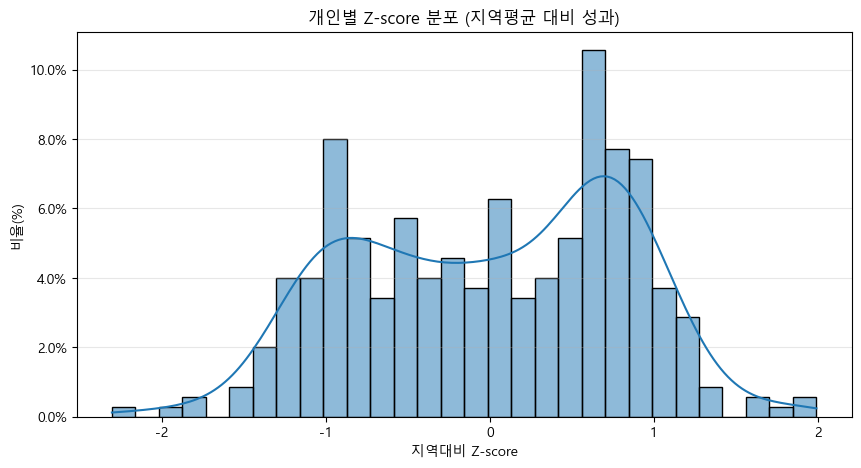

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))
sns.histplot(df["Zscore"], bins=30, kde=True, stat="probability")

plt.xlabel("지역대비 Z-score")
plt.ylabel("비율(%)")
plt.title("개인별 Z-score 분포 (지역평균 대비 성과)")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)
plt.show()


In [11]:
region_stats = df.groupby("지역명").agg(
    평균성사율=("거래성사율", "mean"),
    표준편차=("거래성사율", "std"),
    개수=("거래성사율", "count")
).round(3)

region_stats


,평균성사율,표준편차,개수
지역명,,,
서울특별시 강남구,0.411,0.342,47
서울특별시 강동구,0.407,0.260,6
서울특별시 강북구,0.812,0.161,5
서울특별시 강서구,0.535,0.304,29
서울특별시 관악구,0.499,0.328,67
서울특별시 광진구,0.616,0.322,24
서울특별시 구로구,0.562,0.305,7
서울특별시 금천구,0.489,0.389,19
서울특별시 노원구,0.944,NaN,1


### 개인별 Z-score 생성

In [12]:
# 1) 개인별 지역평균 / 지역표준편차 다시 병합
df["지역평균"] = df.groupby("지역명")["거래성사율"].transform("mean")
df["지역표준편차"] = df.groupby("지역명")["거래성사율"].transform("std")

# 2) 개인별 Z-score 계산
df["Zscore"] = (df["거래성사율"] - df["지역평균"]) / (df["지역표준편차"] + 1e-6)


> A/B/C 기준(분위수) 자동 계산

In [13]:
q30 = df["Zscore"].quantile(0.30)
q70 = df["Zscore"].quantile(0.70)

print("C 등급 상한:", q30)
print("B 등급 상한:", q70)


C 등급 상한: -0.6917038611284914
B 등급 상한: 0.752316133124938


> 개인별 A/B/C 등급 부여

In [14]:
def classify(z):
    if z <= q30:
        return "C"   # 하위 30%
    elif z <= q70:
        return "B"   # 중간 40%
    else:
        return "A"   # 상위 30%

df["등급"] = df["Zscore"].apply(classify)


> 등급분포 확인하기 

In [15]:
df["등급"].value_counts(normalize=True)

등급
B    0.398860
A    0.301994
C    0.299145
Name: proportion, dtype: float64

> 지역별 A/B/C 분포 확인

In [16]:
grade_summary = df.groupby("지역명")["등급"].value_counts().unstack().fillna(0)
grade_summary

등급,A,B,C
지역명,,,
서울특별시 강남구,15.0,15.0,17.0
서울특별시 강동구,1.0,4.0,1.0
서울특별시 강북구,0.0,3.0,2.0
서울특별시 강서구,7.0,15.0,7.0
서울특별시 관악구,20.0,28.0,19.0
서울특별시 광진구,6.0,11.0,7.0
서울특별시 구로구,2.0,3.0,2.0
서울특별시 금천구,7.0,4.0,8.0
서울특별시 노원구,1.0,0.0,0.0


# 구별 매물 수 / 서울시 전체 매물수

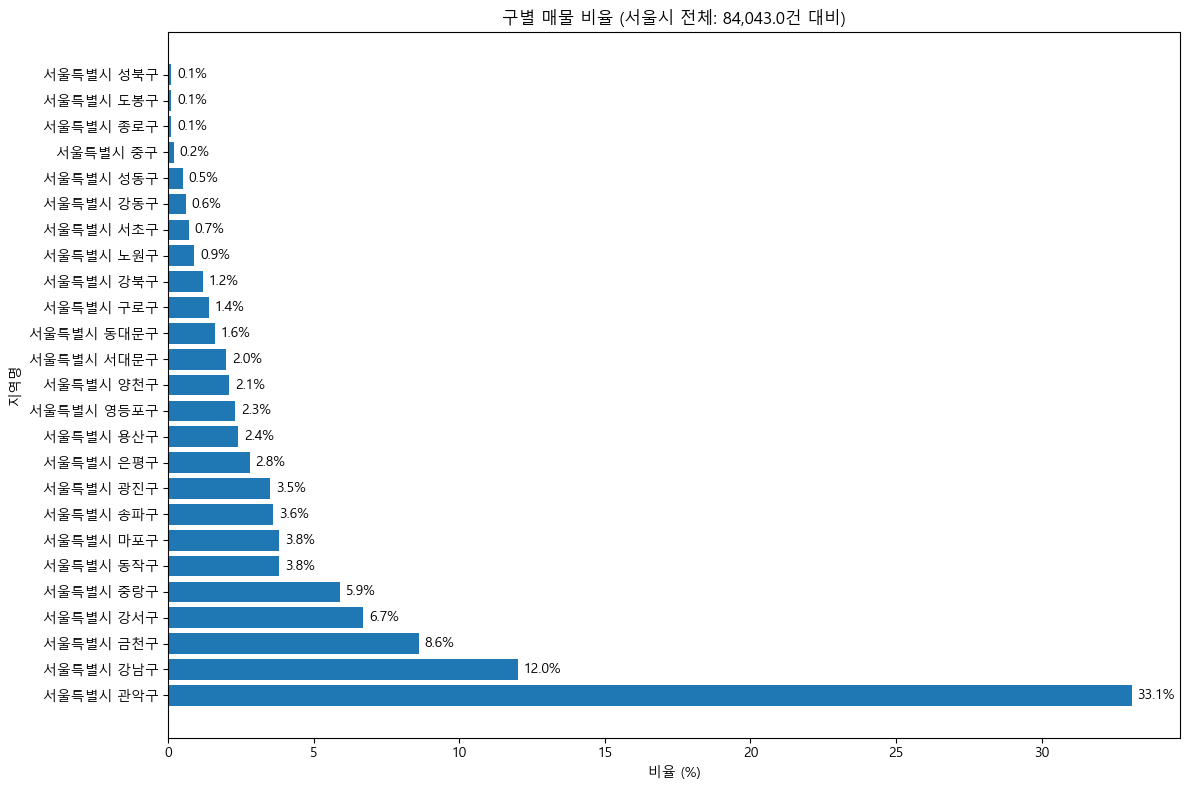

구별 매물 비율:
서울특별시 관악구: 27,829.0건 / 84,043.0건 = 33.1%
서울특별시 강남구: 10,052.0건 / 84,043.0건 = 12.0%
서울특별시 금천구: 7,223.0건 / 84,043.0건 = 8.6%
서울특별시 강서구: 5,669.0건 / 84,043.0건 = 6.7%
서울특별시 중랑구: 4,936.0건 / 84,043.0건 = 5.9%
서울특별시 동작구: 3,195.0건 / 84,043.0건 = 3.8%
서울특별시 마포구: 3,183.0건 / 84,043.0건 = 3.8%
서울특별시 송파구: 3,045.0건 / 84,043.0건 = 3.6%
서울특별시 광진구: 2,928.0건 / 84,043.0건 = 3.5%
서울특별시 은평구: 2,343.0건 / 84,043.0건 = 2.8%
서울특별시 용산구: 2,043.0건 / 84,043.0건 = 2.4%
서울특별시 영등포구: 1,931.0건 / 84,043.0건 = 2.3%
서울특별시 양천구: 1,778.0건 / 84,043.0건 = 2.1%
서울특별시 서대문구: 1,705.0건 / 84,043.0건 = 2.0%
서울특별시 동대문구: 1,376.0건 / 84,043.0건 = 1.6%
서울특별시 구로구: 1,152.0건 / 84,043.0건 = 1.4%
서울특별시 강북구: 991.0건 / 84,043.0건 = 1.2%
서울특별시 노원구: 735.0건 / 84,043.0건 = 0.9%
서울특별시 서초구: 602.0건 / 84,043.0건 = 0.7%
서울특별시 강동구: 512.0건 / 84,043.0건 = 0.6%
서울특별시 성동구: 461.0건 / 84,043.0건 = 0.5%
서울특별시 중구: 140.0건 / 84,043.0건 = 0.2%
서울특별시 종로구: 86.0건 / 84,043.0건 = 0.1%
서울특별시 도봉구: 70.0건 / 84,043.0건 = 0.1%
서울특별시 성북구: 58.0건 / 84,043.0건 = 0.1%


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 매물 수 계산
district_total = df.groupby('지역명')['전체매물'].sum().sort_values(ascending=False)

# 서울시 전체 매물 수
seoul_total = df['전체매물'].sum()

# 비율 계산 (구별 매물 수 / 서울시 전체 매물 수 * 100)
district_ratio = (district_total / seoul_total * 100).round(1)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(district_ratio.index, district_ratio.values)
plt.xlabel('비율 (%)')
plt.ylabel('지역명')
plt.title(f'구별 매물 비율 (서울시 전체: {seoul_total:,}건 대비)')

# 값 표시
for i, v in enumerate(district_ratio.values):
    plt.text(v + 0.2, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

print("구별 매물 비율:")
for region, ratio in district_ratio.items():
    count = district_total[region]
    print(f"{region}: {count:,}건 / {seoul_total:,}건 = {ratio}%")


# 구별 전체 매물 대비 거래된 매물 비율

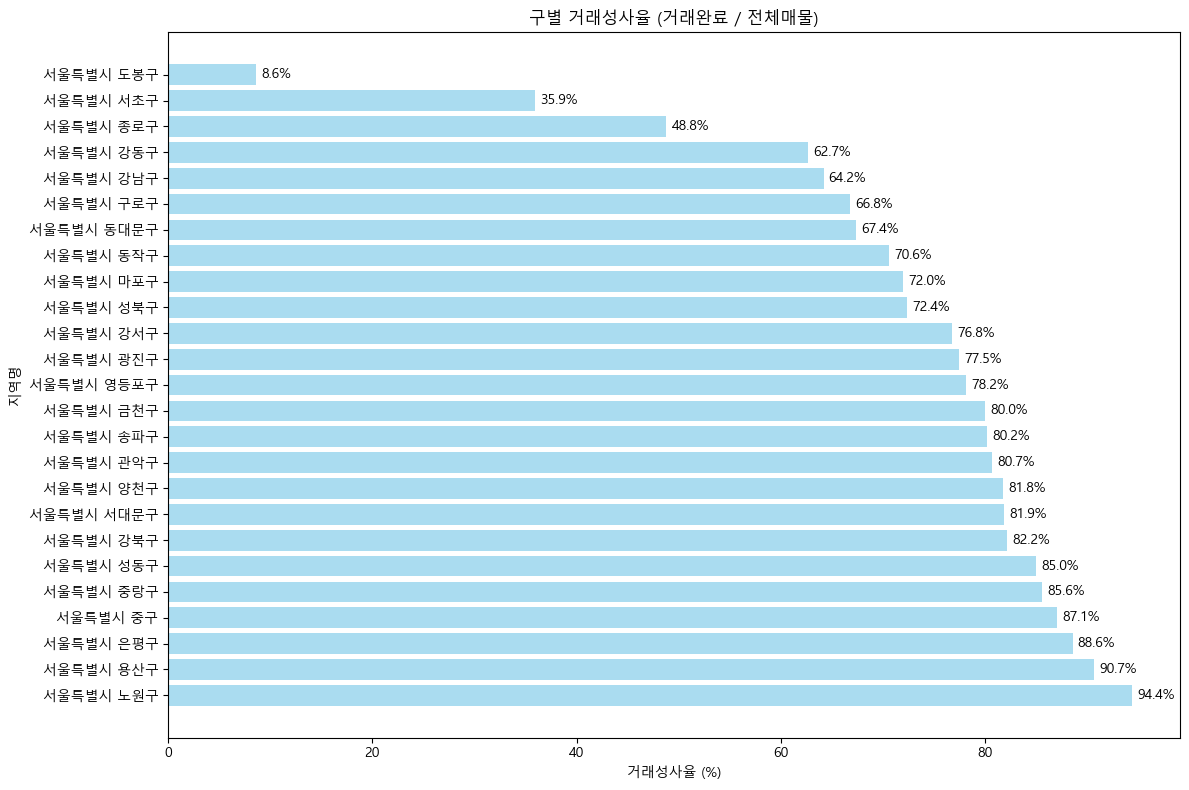

구별 거래성사율:
서울특별시 노원구: 694.0건 / 735.0건 = 94.4%
서울특별시 용산구: 1,852.0건 / 2,043.0건 = 90.7%
서울특별시 은평구: 2,076.0건 / 2,343.0건 = 88.6%
서울특별시 중구: 122.0건 / 140.0건 = 87.1%
서울특별시 중랑구: 4,226.0건 / 4,936.0건 = 85.6%
서울특별시 성동구: 392.0건 / 461.0건 = 85.0%
서울특별시 강북구: 815.0건 / 991.0건 = 82.2%
서울특별시 서대문구: 1,397.0건 / 1,705.0건 = 81.9%
서울특별시 양천구: 1,455.0건 / 1,778.0건 = 81.8%
서울특별시 관악구: 22,468.0건 / 27,829.0건 = 80.7%
서울특별시 송파구: 2,441.0건 / 3,045.0건 = 80.2%
서울특별시 금천구: 5,776.0건 / 7,223.0건 = 80.0%
서울특별시 영등포구: 1,511.0건 / 1,931.0건 = 78.2%
서울특별시 광진구: 2,268.0건 / 2,928.0건 = 77.5%
서울특별시 강서구: 4,352.0건 / 5,669.0건 = 76.8%
서울특별시 성북구: 42.0건 / 58.0건 = 72.4%
서울특별시 마포구: 2,291.0건 / 3,183.0건 = 72.0%
서울특별시 동작구: 2,255.0건 / 3,195.0건 = 70.6%
서울특별시 동대문구: 928.0건 / 1,376.0건 = 67.4%
서울특별시 구로구: 770.0건 / 1,152.0건 = 66.8%
서울특별시 강남구: 6,454.0건 / 10,052.0건 = 64.2%
서울특별시 강동구: 321.0건 / 512.0건 = 62.7%
서울특별시 종로구: 42.0건 / 86.0건 = 48.8%
서울특별시 서초구: 216.0건 / 602.0건 = 35.9%
서울특별시 도봉구: 6.0건 / 70.0건 = 8.6%


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 거래완료 건수와 전체매물 수 계산
district_stats = df.groupby('지역명').agg({
    '거래완료': 'sum',
    '전체매물': 'sum'
}).reset_index()

# 거래성사율 계산
district_stats['거래성사율'] = (district_stats['거래완료'] / district_stats['전체매물'] * 100).round(1)

# 거래성사율 기준으로 내림차순 정렬
district_stats = district_stats.sort_values('거래성사율', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(district_stats['지역명'], district_stats['거래성사율'], color='skyblue', alpha=0.7)
plt.xlabel('거래성사율 (%)')
plt.ylabel('지역명')
plt.title('구별 거래성사율 (거래완료 / 전체매물)')

# 값 표시
for i, v in enumerate(district_stats['거래성사율']):
    plt.text(v + 0.5, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

# 통계 출력
print("구별 거래성사율:")
for _, row in district_stats.iterrows():
    print(f"{row['지역명']}: {row['거래완료']:,}건 / {row['전체매물']:,}건 = {row['거래성사율']}%")


# 구별 매물이 500건 이상만 추출하기

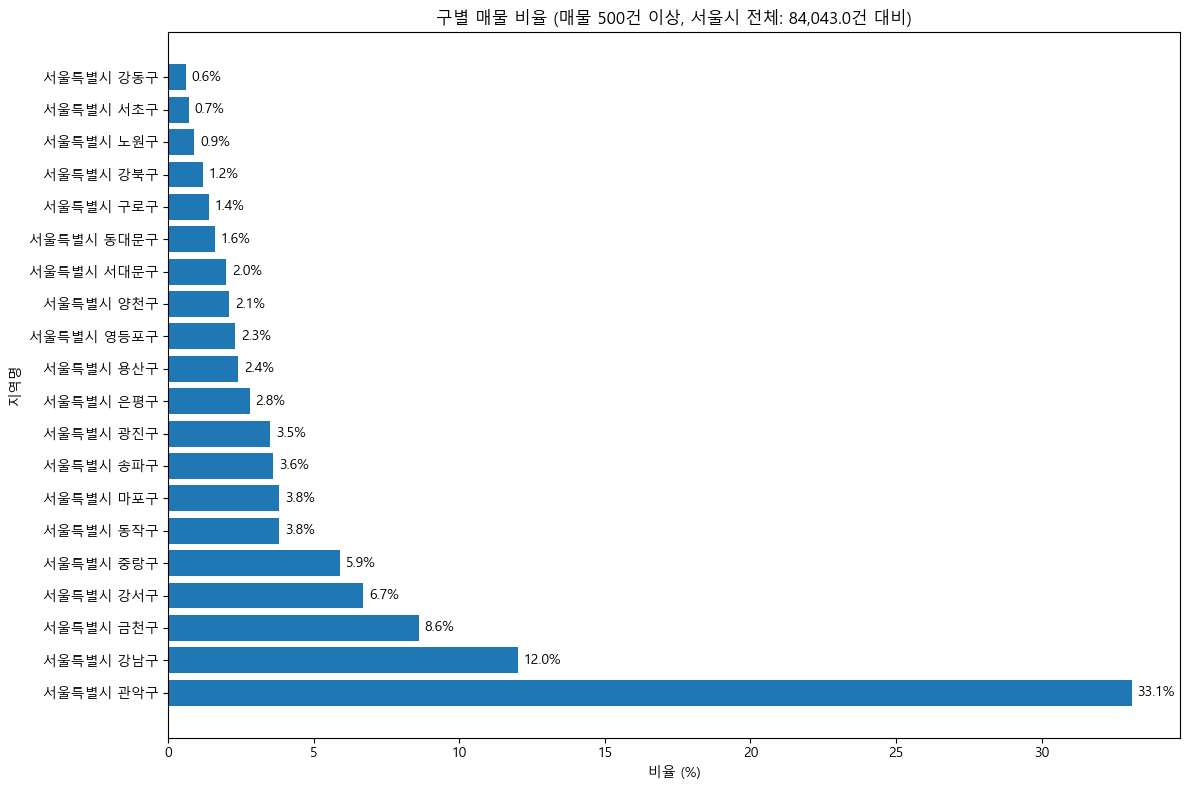

구별 매물 비율 (매물 500건 이상):
서울특별시 관악구: 27,829.0건 / 84,043.0건 = 33.1%
서울특별시 강남구: 10,052.0건 / 84,043.0건 = 12.0%
서울특별시 금천구: 7,223.0건 / 84,043.0건 = 8.6%
서울특별시 강서구: 5,669.0건 / 84,043.0건 = 6.7%
서울특별시 중랑구: 4,936.0건 / 84,043.0건 = 5.9%
서울특별시 동작구: 3,195.0건 / 84,043.0건 = 3.8%
서울특별시 마포구: 3,183.0건 / 84,043.0건 = 3.8%
서울특별시 송파구: 3,045.0건 / 84,043.0건 = 3.6%
서울특별시 광진구: 2,928.0건 / 84,043.0건 = 3.5%
서울특별시 은평구: 2,343.0건 / 84,043.0건 = 2.8%
서울특별시 용산구: 2,043.0건 / 84,043.0건 = 2.4%
서울특별시 영등포구: 1,931.0건 / 84,043.0건 = 2.3%
서울특별시 양천구: 1,778.0건 / 84,043.0건 = 2.1%
서울특별시 서대문구: 1,705.0건 / 84,043.0건 = 2.0%
서울특별시 동대문구: 1,376.0건 / 84,043.0건 = 1.6%
서울특별시 구로구: 1,152.0건 / 84,043.0건 = 1.4%
서울특별시 강북구: 991.0건 / 84,043.0건 = 1.2%
서울특별시 노원구: 735.0건 / 84,043.0건 = 0.9%
서울특별시 서초구: 602.0건 / 84,043.0건 = 0.7%
서울특별시 강동구: 512.0건 / 84,043.0건 = 0.6%

필터링된 구 개수: 20개
전체 구 개수: 25개


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 매물 수 계산
district_total = df.groupby('지역명')['전체매물'].sum().sort_values(ascending=False)

# 매물 500건 이상인 구만 필터링
filtered_district_total = district_total[district_total >= 500]

# 서울시 전체 매물 수
seoul_total = df['전체매물'].sum()

# 비율 계산 (구별 매물 수 / 서울시 전체 매물 수 * 100)
filtered_district_ratio = (filtered_district_total / seoul_total * 100).round(1)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(filtered_district_ratio.index, filtered_district_ratio.values)
plt.xlabel('비율 (%)')
plt.ylabel('지역명')
plt.title(f'구별 매물 비율 (매물 500건 이상, 서울시 전체: {seoul_total:,}건 대비)')

# 값 표시
for i, v in enumerate(filtered_district_ratio.values):
    plt.text(v + 0.2, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

print("구별 매물 비율 (매물 500건 이상):")
for region, ratio in filtered_district_ratio.items():
    count = filtered_district_total[region]
    print(f"{region}: {count:,}건 / {seoul_total:,}건 = {ratio}%")

print(f"\n필터링된 구 개수: {len(filtered_district_ratio)}개")
print(f"전체 구 개수: {len(district_total)}개")


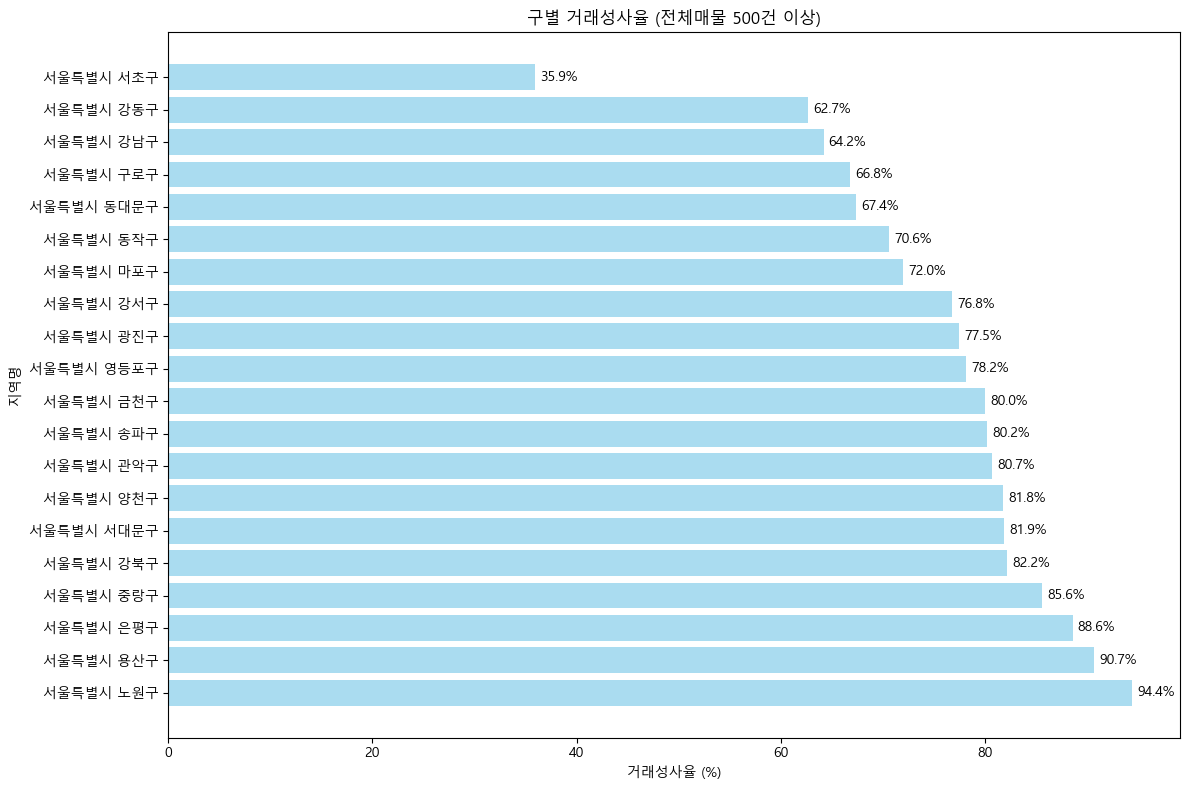

구별 거래성사율 (전체매물 500건 이상):
서울특별시 노원구: 694.0건 / 735.0건 = 94.4%
서울특별시 용산구: 1,852.0건 / 2,043.0건 = 90.7%
서울특별시 은평구: 2,076.0건 / 2,343.0건 = 88.6%
서울특별시 중랑구: 4,226.0건 / 4,936.0건 = 85.6%
서울특별시 강북구: 815.0건 / 991.0건 = 82.2%
서울특별시 서대문구: 1,397.0건 / 1,705.0건 = 81.9%
서울특별시 양천구: 1,455.0건 / 1,778.0건 = 81.8%
서울특별시 관악구: 22,468.0건 / 27,829.0건 = 80.7%
서울특별시 송파구: 2,441.0건 / 3,045.0건 = 80.2%
서울특별시 금천구: 5,776.0건 / 7,223.0건 = 80.0%
서울특별시 영등포구: 1,511.0건 / 1,931.0건 = 78.2%
서울특별시 광진구: 2,268.0건 / 2,928.0건 = 77.5%
서울특별시 강서구: 4,352.0건 / 5,669.0건 = 76.8%
서울특별시 마포구: 2,291.0건 / 3,183.0건 = 72.0%
서울특별시 동작구: 2,255.0건 / 3,195.0건 = 70.6%
서울특별시 동대문구: 928.0건 / 1,376.0건 = 67.4%
서울특별시 구로구: 770.0건 / 1,152.0건 = 66.8%
서울특별시 강남구: 6,454.0건 / 10,052.0건 = 64.2%
서울특별시 강동구: 321.0건 / 512.0건 = 62.7%
서울특별시 서초구: 216.0건 / 602.0건 = 35.9%

필터링된 구 개수: 20개
전체 구 개수: 25개


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 거래완료 건수와 전체매물 수 계산
district_stats = df.groupby('지역명').agg({
    '거래완료': 'sum',
    '전체매물': 'sum'
}).reset_index()

# 거래성사율 계산
district_stats['거래성사율'] = (district_stats['거래완료'] / district_stats['전체매물'] * 100).round(1)

# 전체매물 500건 이상인 구만 필터링
filtered_district_stats = district_stats[district_stats['전체매물'] >= 500]

# 거래성사율 기준으로 내림차순 정렬
filtered_district_stats = filtered_district_stats.sort_values('거래성사율', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(filtered_district_stats['지역명'], filtered_district_stats['거래성사율'], color='skyblue', alpha=0.7)
plt.xlabel('거래성사율 (%)')
plt.ylabel('지역명')
plt.title('구별 거래성사율 (전체매물 500건 이상)')

# 값 표시
for i, v in enumerate(filtered_district_stats['거래성사율']):
    plt.text(v + 0.5, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

# 통계 출력
print("구별 거래성사율 (전체매물 500건 이상):")
for _, row in filtered_district_stats.iterrows():
    print(f"{row['지역명']}: {row['거래완료']:,}건 / {row['전체매물']:,}건 = {row['거래성사율']}%")

print(f"\n필터링된 구 개수: {len(filtered_district_stats)}개")
print(f"전체 구 개수: {len(district_stats)}개")


# 서울 전체 중개업소 대비 구별 중개소 비율

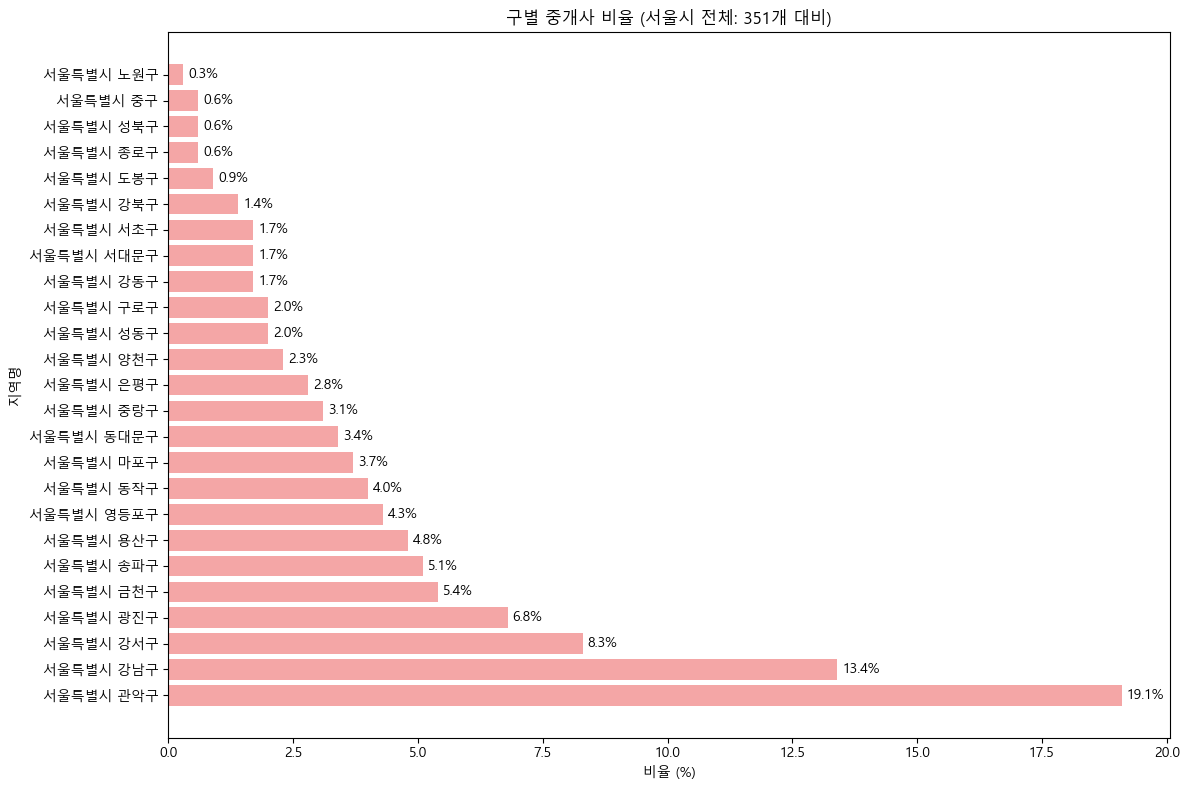

구별 중개사 비율 (서울시 전체 대비):
서울특별시 관악구: 67개 / 351개 = 19.1%
서울특별시 강남구: 47개 / 351개 = 13.4%
서울특별시 강서구: 29개 / 351개 = 8.3%
서울특별시 광진구: 24개 / 351개 = 6.8%
서울특별시 금천구: 19개 / 351개 = 5.4%
서울특별시 송파구: 18개 / 351개 = 5.1%
서울특별시 용산구: 17개 / 351개 = 4.8%
서울특별시 영등포구: 15개 / 351개 = 4.3%
서울특별시 동작구: 14개 / 351개 = 4.0%
서울특별시 마포구: 13개 / 351개 = 3.7%
서울특별시 동대문구: 12개 / 351개 = 3.4%
서울특별시 중랑구: 11개 / 351개 = 3.1%
서울특별시 은평구: 10개 / 351개 = 2.8%
서울특별시 양천구: 8개 / 351개 = 2.3%
서울특별시 성동구: 7개 / 351개 = 2.0%
서울특별시 구로구: 7개 / 351개 = 2.0%
서울특별시 강동구: 6개 / 351개 = 1.7%
서울특별시 서대문구: 6개 / 351개 = 1.7%
서울특별시 서초구: 6개 / 351개 = 1.7%
서울특별시 강북구: 5개 / 351개 = 1.4%
서울특별시 도봉구: 3개 / 351개 = 0.9%
서울특별시 종로구: 2개 / 351개 = 0.6%
서울특별시 성북구: 2개 / 351개 = 0.6%
서울특별시 중구: 2개 / 351개 = 0.6%
서울특별시 노원구: 1개 / 351개 = 0.3%

서울시 전체: 351개 (100.0%)


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구별 중개사 수 계산
district_broker_count = df.groupby('지역명').size().sort_values(ascending=False)

# 서울시 전체 중개사 수
seoul_total_brokers = district_broker_count.sum()

# 비율 계산 (구별 중개사 수 / 서울시 전체 중개사 수 * 100)
district_broker_ratio = (district_broker_count / seoul_total_brokers * 100).round(1)

# 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(district_broker_ratio.index, district_broker_ratio.values, color='lightcoral', alpha=0.7)
plt.xlabel('비율 (%)')
plt.ylabel('지역명')
plt.title(f'구별 중개사 비율 (서울시 전체: {seoul_total_brokers}개 대비)')

# 값 표시
for i, v in enumerate(district_broker_ratio.values):
    plt.text(v + 0.1, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

# 통계 출력
print("구별 중개사 비율 (서울시 전체 대비):")
for region, ratio in district_broker_ratio.items():
    count = district_broker_count[region]
    print(f"{region}: {count}개 / {seoul_total_brokers}개 = {ratio}%")

print(f"\n서울시 전체: {seoul_total_brokers}개 (100.0%)")


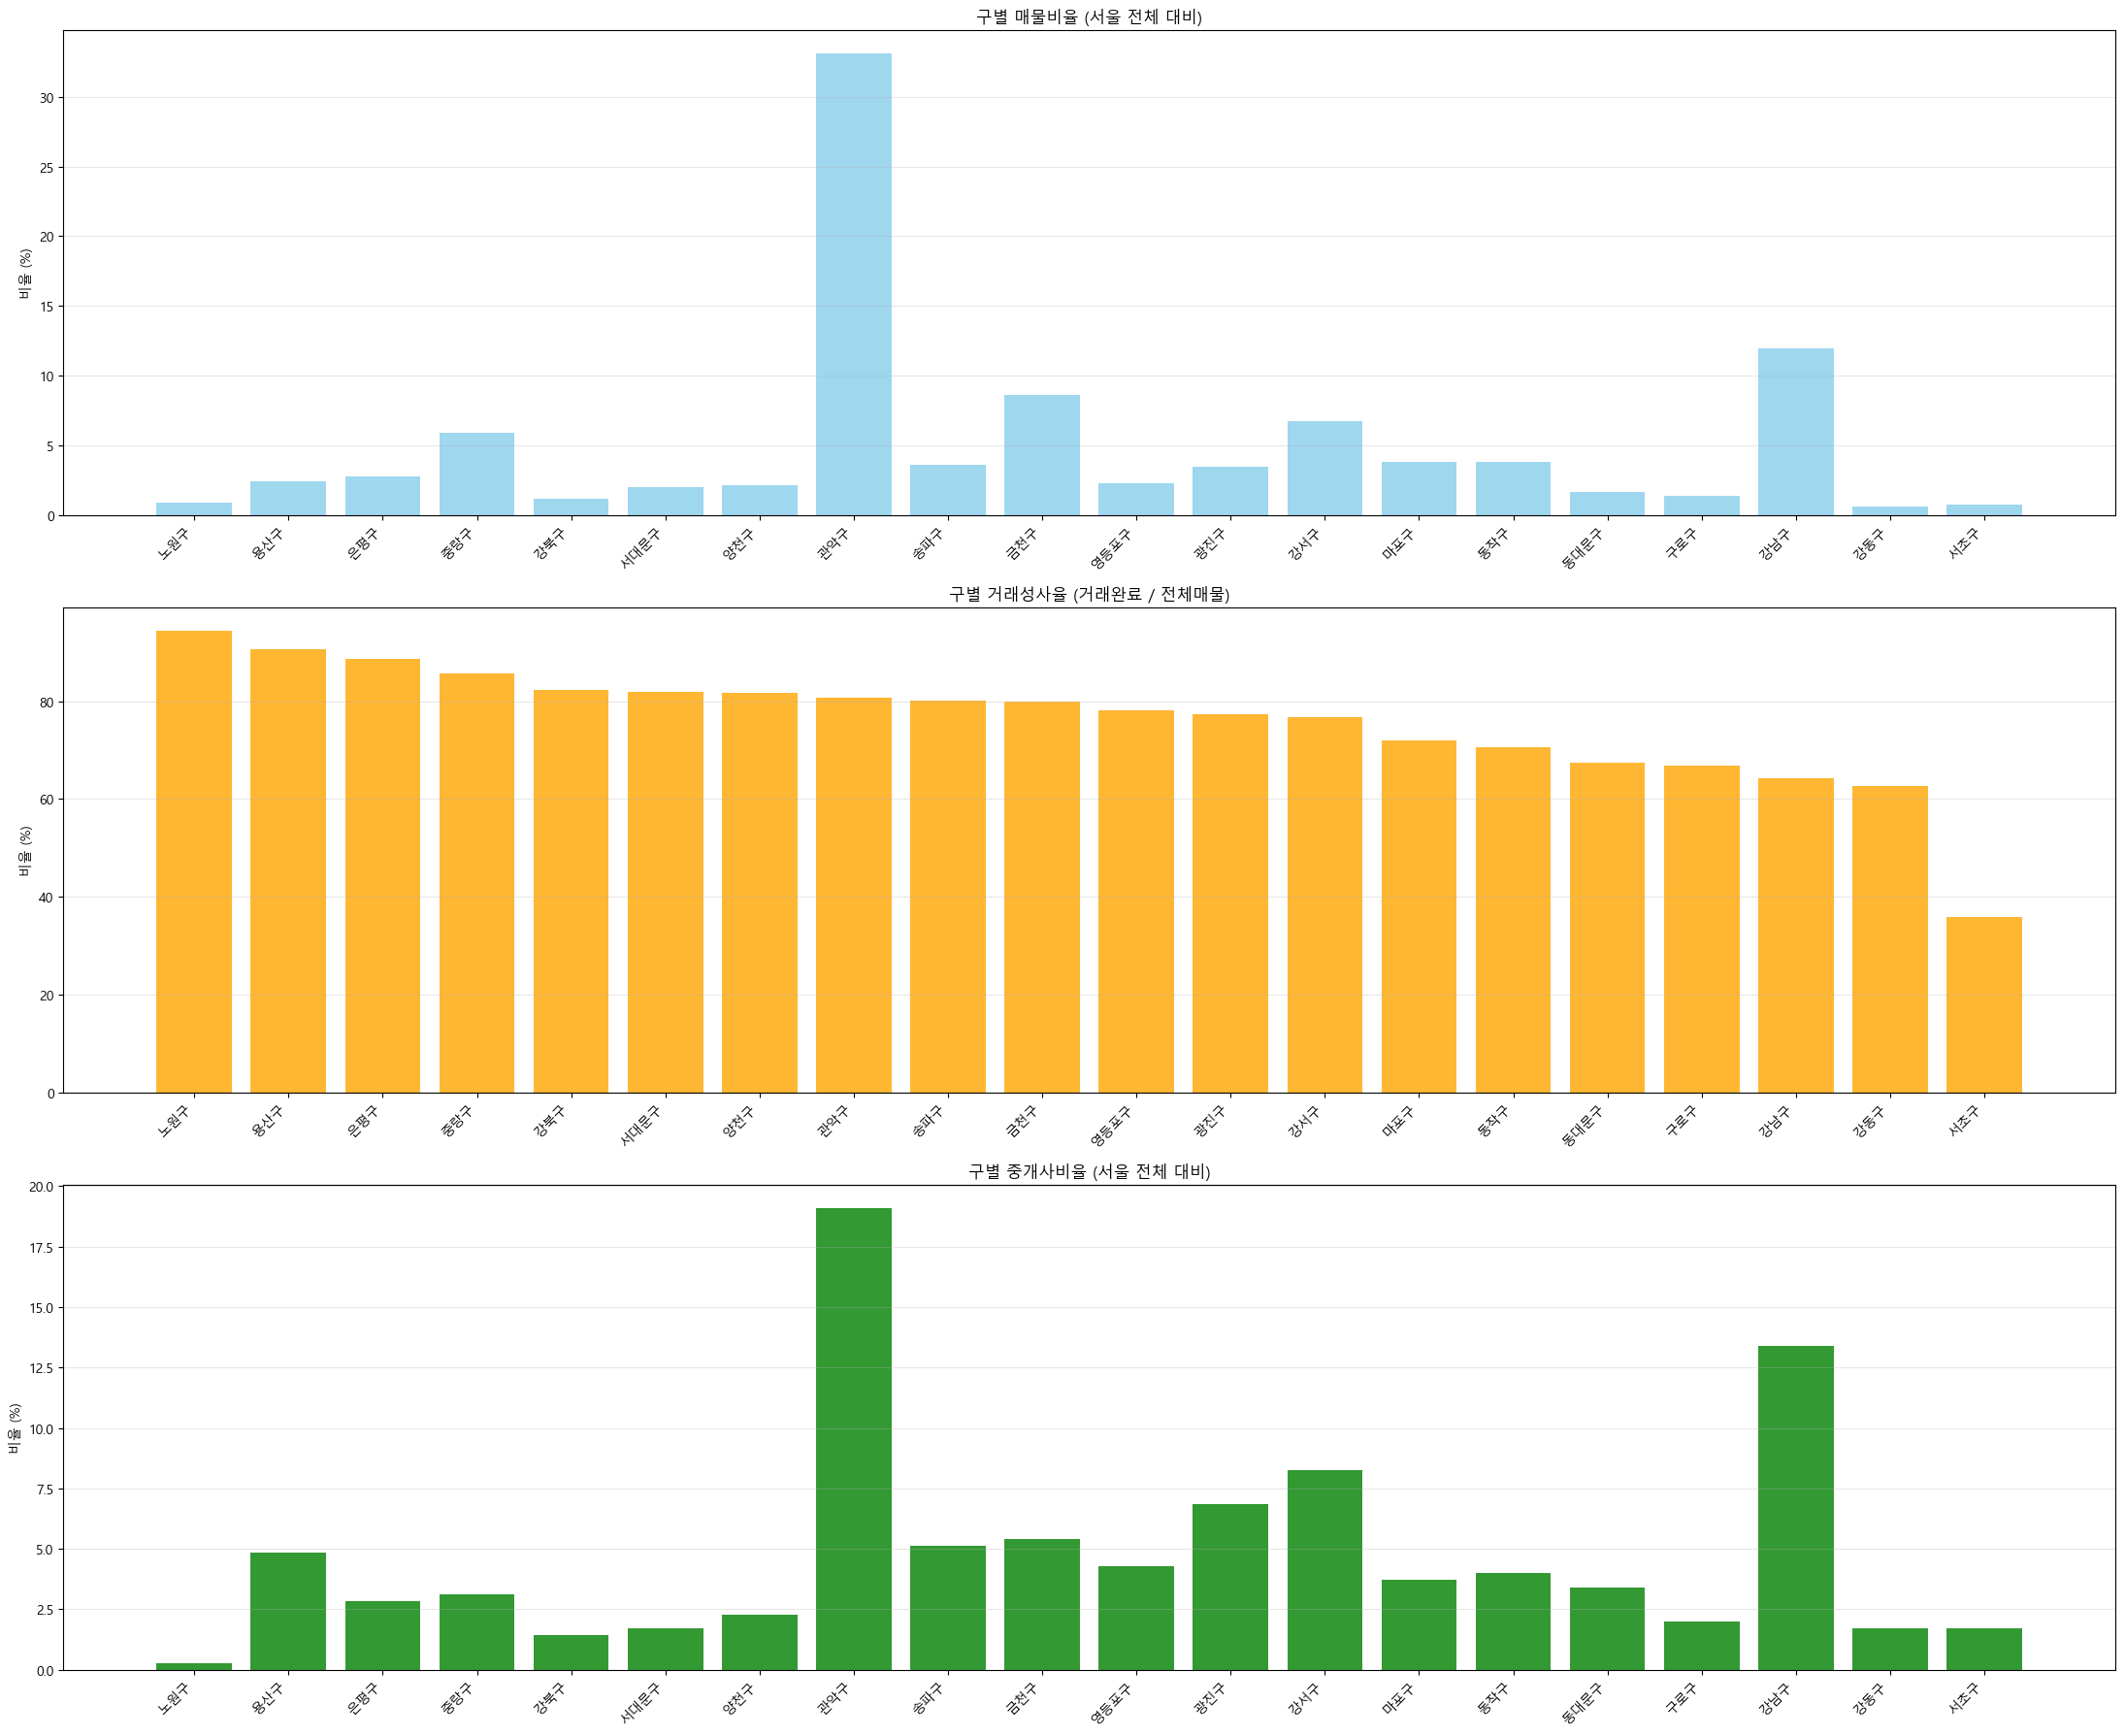

구별 지표 비교 (서울시 전체 대비 비율):
     지역명  매물비율(%)  거래성사율(%)  중개사비율(%)     전체매물
8    노원구      0.9      94.4       0.3    735.0
20   용산구      2.4      90.7       4.8   2043.0
21   은평구      2.8      88.6       2.8   2343.0
24   중랑구      5.9      85.6       3.1   4936.0
2    강북구      1.2      82.2       1.4    991.0
13  서대문구      2.0      81.9       1.7   1705.0
18   양천구      2.1      81.8       2.3   1778.0
4    관악구     33.1      80.7      19.1  27829.0
17   송파구      3.6      80.2       5.1   3045.0
7    금천구      8.6      80.0       5.4   7223.0
19  영등포구      2.3      78.2       4.3   1931.0
5    광진구      3.5      77.5       6.8   2928.0
3    강서구      6.7      76.8       8.3   5669.0
12   마포구      3.8      72.0       3.7   3183.0
11   동작구      3.8      70.6       4.0   3195.0
10  동대문구      1.6      67.4       3.4   1376.0
6    구로구      1.4      66.8       2.0   1152.0
0    강남구     12.0      64.2      13.4  10052.0
1    강동구      0.6      62.7       1.7    512.0
14   서초구      0.7      35.9       1

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================
# 0) 지역명에서 '서울특별시', '서울시' 제거
# ================================
df['지역명'] = df['지역명'].apply(lambda x: x.split()[-1])


# ================================
# 1) 구별 서울 전체 매물 대비 비율
# ================================
district_total = df.groupby('지역명')['전체매물'].sum()
seoul_total = df['전체매물'].sum()
district_ratio = (district_total / seoul_total * 100)

# ================================
# 2) 구별 거래성사율 (거래완료 / 전체매물)
# ================================
district_stats = df.groupby('지역명').agg({
    '거래완료': 'sum',
    '전체매물': 'sum'
})
district_success_rate = (district_stats['거래완료'] / district_stats['전체매물'] * 100)

# ================================
# 3) 구별 중개사 수 비율 (서울 전체 대비)
# ================================
district_agent_count = df.groupby('지역명').size()
seoul_total_agents = district_agent_count.sum()
district_agent_ratio = (district_agent_count / seoul_total_agents * 100)

# ================================
# 4) 하나의 DF로 합치기 + 매물 500건 이상 필터링
# ================================
combined = pd.DataFrame({
    '지역명': district_ratio.index,
    '매물비율(%)': district_ratio.values,
    '거래성사율(%)': district_success_rate.values,
    '중개사비율(%)': district_agent_ratio.values,
    '전체매물': district_stats['전체매물'].values
})

# 매물 500건 이상인 지역만 필터링
combined = combined[combined['전체매물'] >= 500]

# 보기 좋게 거래성사율 기준 정렬
combined = combined.sort_values('거래성사율(%)', ascending=False)

regions = combined['지역명']
x = np.arange(len(regions))

# ================================
# 5) Subplot 3개 그리기 (각각 x축 지역명 표시)
# ================================
fig, axes = plt.subplots(3, 1, figsize=(22, 18))  # sharex 제거

# --- 1. 매물비율 ---
axes[0].bar(x, combined['매물비율(%)'], color='skyblue', alpha=0.8)
axes[0].set_title("구별 매물비율 (서울 전체 대비)")
axes[0].set_ylabel("비율 (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# --- 2. 거래성사율 ---
axes[1].bar(x, combined['거래성사율(%)'], color='orange', alpha=0.8)
axes[1].set_title("구별 거래성사율 (거래완료 / 전체매물)")
axes[1].set_ylabel("비율 (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(regions, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# --- 3. 중개사비율 ---
axes[2].bar(x, combined['중개사비율(%)'], color='green', alpha=0.8)
axes[2].set_title("구별 중개사비율 (서울 전체 대비)")
axes[2].set_ylabel("비율 (%)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(regions, rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ---- 통계 출력 ----
print("구별 지표 비교 (서울시 전체 대비 비율):")
print(combined.round(1))
print(f"\n서울시 전체 매물: {seoul_total:,}건")
print(f"서울시 전체 중개사: {seoul_total_agents}개")


# Advanced Evaluation & Graphs (Integrated)


Loaded data from ../../../../../data/ML/office_features.csv
Analyzing 351 samples with 12 features...
Evaluating LogisticRegression...


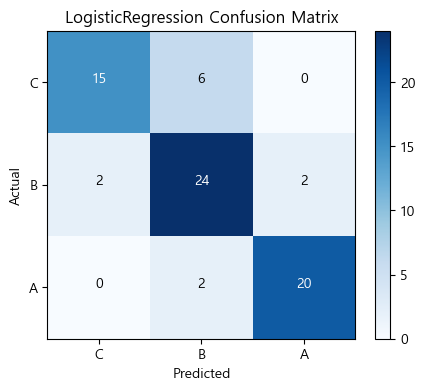

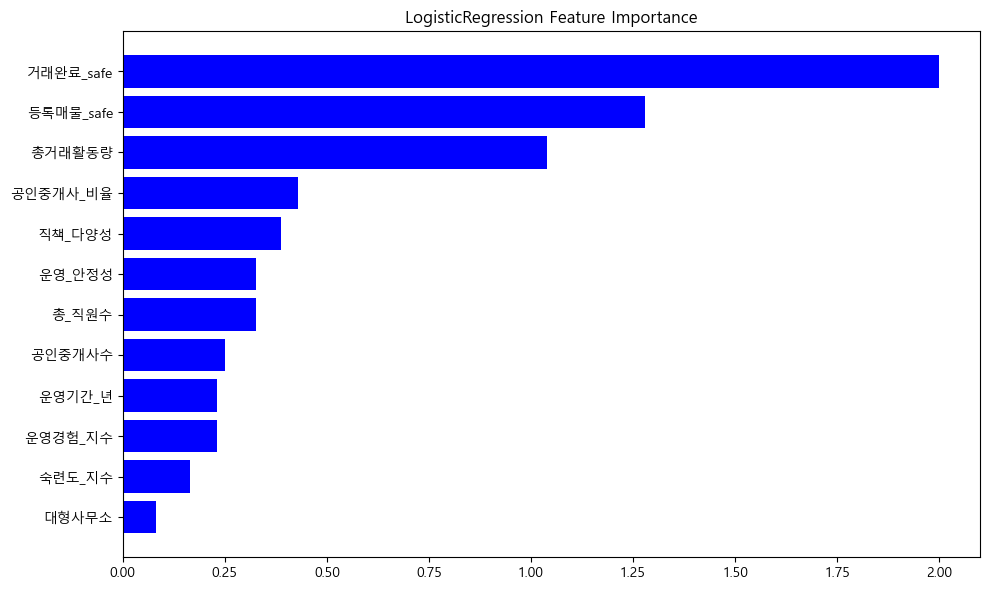

Evaluating RandomForest...


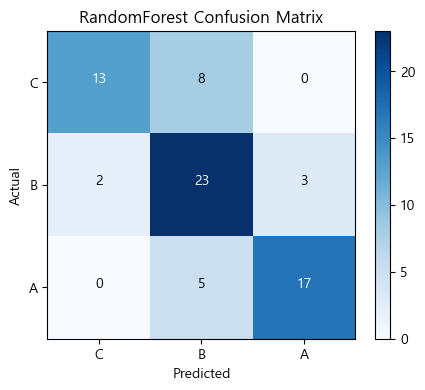

Evaluating XGBoost...


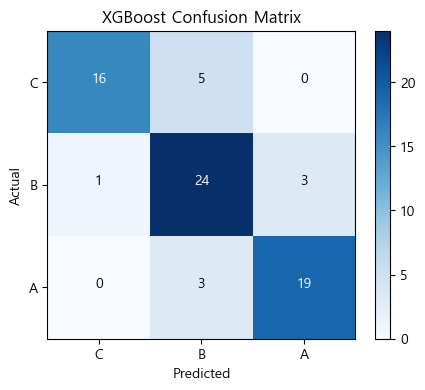

Evaluating CatBoost...


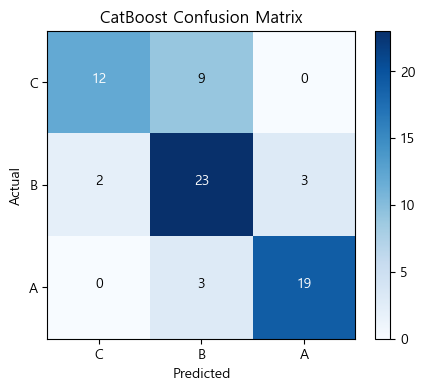

Evaluating SVM...


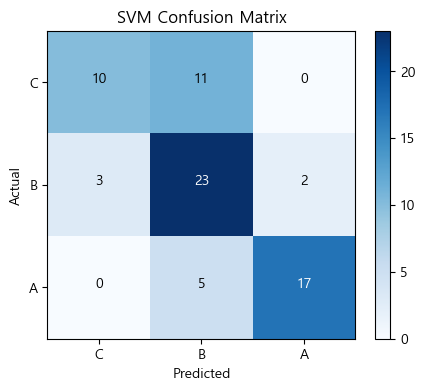

Evaluating DecisionTree...


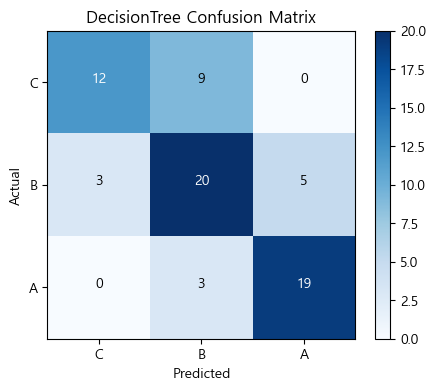

Evaluating Ensemble...


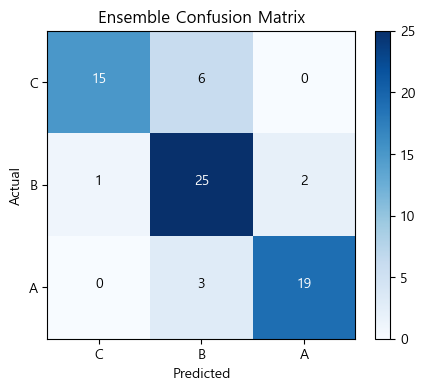


Evaluation Results:


,Model,Accuracy,Train_Acc,Overfitting,F1_Macro,ROC_AUC,Log_Loss
0,LogisticRegression,0.8310,0.8500,0.0190,0.8329,0.9557,0.4299
1,RandomForest,0.7465,0.8929,0.1464,0.7502,0.9008,0.6507
2,XGBoost,0.8310,0.9679,0.1369,0.8352,0.9312,0.4896
3,CatBoost,0.7606,0.8607,0.1002,0.7598,0.9238,0.5770
4,SVM,0.7042,0.8357,0.1315,0.7014,0.8923,0.6023
5,DecisionTree,0.7183,0.8821,0.1638,0.7198,0.8638,3.4715
6,Ensemble,0.8310,0.9357,0.1047,0.8337,0.9441,0.4935


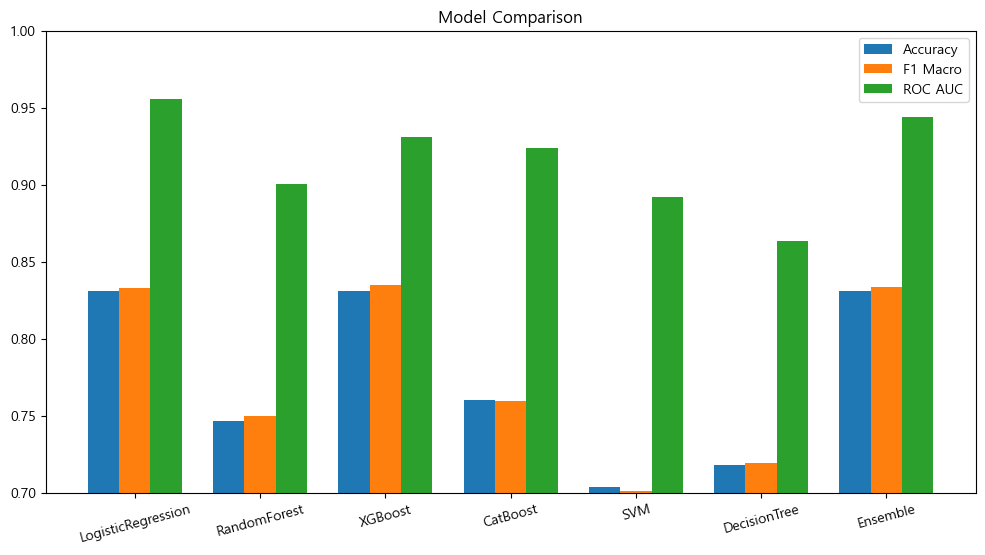

In [23]:

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# Output directory for assets (relative to notebook)
# Notebook at: apps/reco/models/trust_model/data_preprocessing/
# Assets at: apps/reco/models/trust_model/result/assets/
# Rel path: ../result/assets
ASSETS_DIR = "../result/assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

# Data Path
# apps/reco/models/trust_model/data_preprocessing/ -> ../../../../../data/ML/office_features.csv
DATA_PATH = '../../../../../data/ML/office_features.csv'

def load_data_eval():
    try:
        df = pd.read_csv(DATA_PATH)
        print(f"Loaded data from {DATA_PATH}")
    except FileNotFoundError:
        # Fallback to absolute
        abs_path = r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/ML/office_features.csv"
        df = pd.read_csv(abs_path)
        print(f"Loaded data from {abs_path}")
        
    y = df["신뢰도등급_숫자"] if "신뢰도등급_숫자" in df.columns else df["신뢰도등급"].map({'A': 2, 'B': 1, 'C': 0})
    
    selected_features = [
        "거래완료_safe", "등록매물_safe", "총거래활동량",
        "총_직원수", "공인중개사수", "공인중개사_비율",
        "운영기간_년", "운영경험_지수", "숙련도_지수", "운영_안정성",
        "대형사무소", "직책_다양성"
    ]
    X = df[selected_features].replace([np.inf, -np.inf], 0).fillna(0)
    return X, y

def get_models():
    lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
    rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=4, random_state=42)
    xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42, eval_metric='mlogloss')
    cat = CatBoostClassifier(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_state=42)
    svm = SVC(probability=True, random_state=42)
    dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    
    voting = VotingClassifier(
        estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
        voting='soft'
    )
    
    return {
        "LogisticRegression": lr,
        "RandomForest": rf,
        "XGBoost": xgb,
        "CatBoost": cat,
        "SVM": svm,
        "DecisionTree": dt,
        "Ensemble": voting
    }

def evaluate_models_notebook():
    X, y = load_data_eval()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    print(f"Analyzing {len(X)} samples with {len(X.columns)} features...")
    
    for name, model in get_models().items():
        print(f"Evaluating {name}...")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        try:
            auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
            ll = log_loss(y_test, y_prob)
        except:
            auc = 0
            ll = 0
            
        train_pred = model.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        overfitting = train_acc - acc
        
        cm = confusion_matrix(y_test, y_pred)
        
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Train_Acc": train_acc,
            "Overfitting": overfitting,
            "F1_Macro": f1_macro,
            "ROC_AUC": auc,
            "Log_Loss": ll
        })
        
        # Plot Confusion Matrix inline
        plt.figure(figsize=(5, 4))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'{name} Confusion Matrix')
        plt.colorbar()
        tick_marks = np.arange(len(['C','B','A']))
        plt.xticks(tick_marks, ['C','B','A'])
        plt.yticks(tick_marks, ['C','B','A'])
        thresh = cm.max() / 2.
        for i, j in np.ndindex(cm.shape):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

        # Feature Importance for LR
        if name == "LogisticRegression":
            importance = np.mean(np.abs(model.coef_), axis=0)
            features = X.columns
            indices = np.argsort(importance)
            plt.figure(figsize=(10, 6))
            plt.title('LogisticRegression Feature Importance')
            plt.barh(range(len(indices)), importance[indices], color='b', align='center')
            plt.yticks(range(len(indices)), [features[i] for i in indices])
            plt.tight_layout()
            plt.show()

    res_df = pd.DataFrame(results)
    print("\nEvaluation Results:")
    display(res_df.round(4))
    
    # Comparison Plot
    plt.figure(figsize=(12, 6))
    models = res_df['Model']
    x = np.arange(len(models))
    width = 0.25
    plt.bar(x - width, res_df['Accuracy'], width, label='Accuracy')
    plt.bar(x, res_df['F1_Macro'], width, label='F1 Macro')
    plt.bar(x + width, res_df['ROC_AUC'], width, label='ROC AUC')
    plt.xticks(x, models, rotation=15)
    plt.legend()
    plt.ylim(0.7, 1.0)
    plt.title("Model Comparison")
    plt.show()

evaluate_models_notebook()


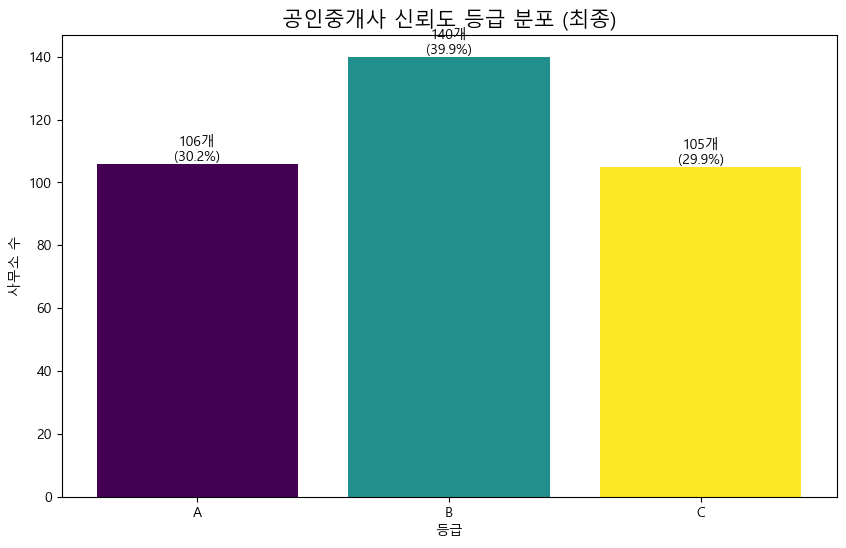

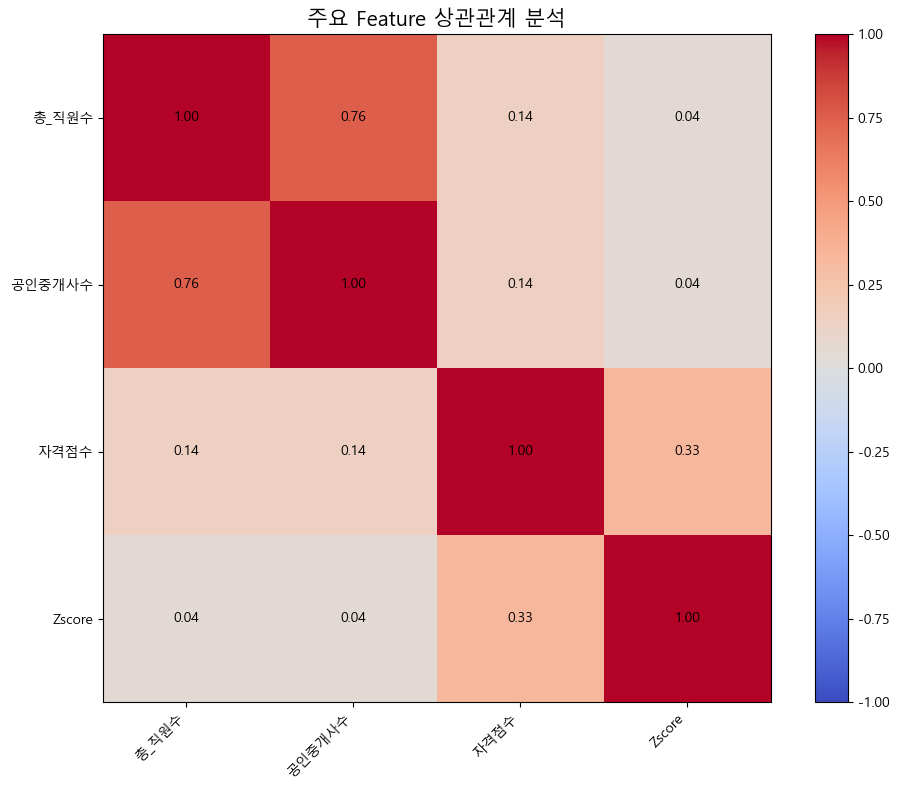

In [24]:

# Graph Generation Section
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Note: Seaborn is removed to avoid errors, using pure matplotlib

def generate_graphs_notebook():
    # Load target data
    DATA_PATH_TARGET = '../../../../../data/ML/office_target.csv'
    try:
        df = pd.read_csv(DATA_PATH_TARGET)
    except Exception:
        # Fallback
        try:
             df = pd.read_csv("c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/ML/office_target.csv")
        except:
             print("Could not load office_target.csv for graphs")
             return

    # Target Distribution
    if '신뢰도등급' in df.columns:
        plt.figure(figsize=(10, 6))
        counts = df['신뢰도등급'].value_counts().reindex(['A', 'B', 'C']).fillna(0)
        colors = ['#440154', '#21908d', '#fde725']
        
        bars = plt.bar(counts.index, counts.values, color=colors)
        plt.title('공인중개사 신뢰도 등급 분포 (최종)', fontsize=15)
        plt.xlabel('등급')
        plt.ylabel('사무소 수')
        
        for rect in bars:
            height = rect.get_height()
            plt.text(rect.get_x() + rect.get_width()/2.0, height,
                     f'{int(height)}개\n({height/len(df)*100:.1f}%)',
                     ha='center', va='bottom')
        plt.show()

    # Correlation
    cols = [
        "거래완료_safe", "등록매물_safe", "총거래활동량", "총_직원수",
        "공인중개사수", "운영기간_년", "숙련도_지수", "자격점수", "Zscore"
    ]
    existing_cols = [c for c in cols if c in df.columns]
    if existing_cols:
        corr_df = df[existing_cols].corr()
        plt.figure(figsize=(10, 8))
        plt.imshow(corr_df, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(corr_df)), corr_df.columns, rotation=45, ha='right')
        plt.yticks(range(len(corr_df)), corr_df.columns)
        plt.title('주요 Feature 상관관계 분석', fontsize=15)
        
        for i in range(len(corr_df)):
            for j in range(len(corr_df)):
                plt.text(j, i, f'{corr_df.iloc[i, j]:.2f}',
                         ha='center', va='center', color='black')
        plt.tight_layout()
        plt.show()

generate_graphs_notebook()


## 📊 타겟 및 모든 피처와의 상관관계 히트맵 분석


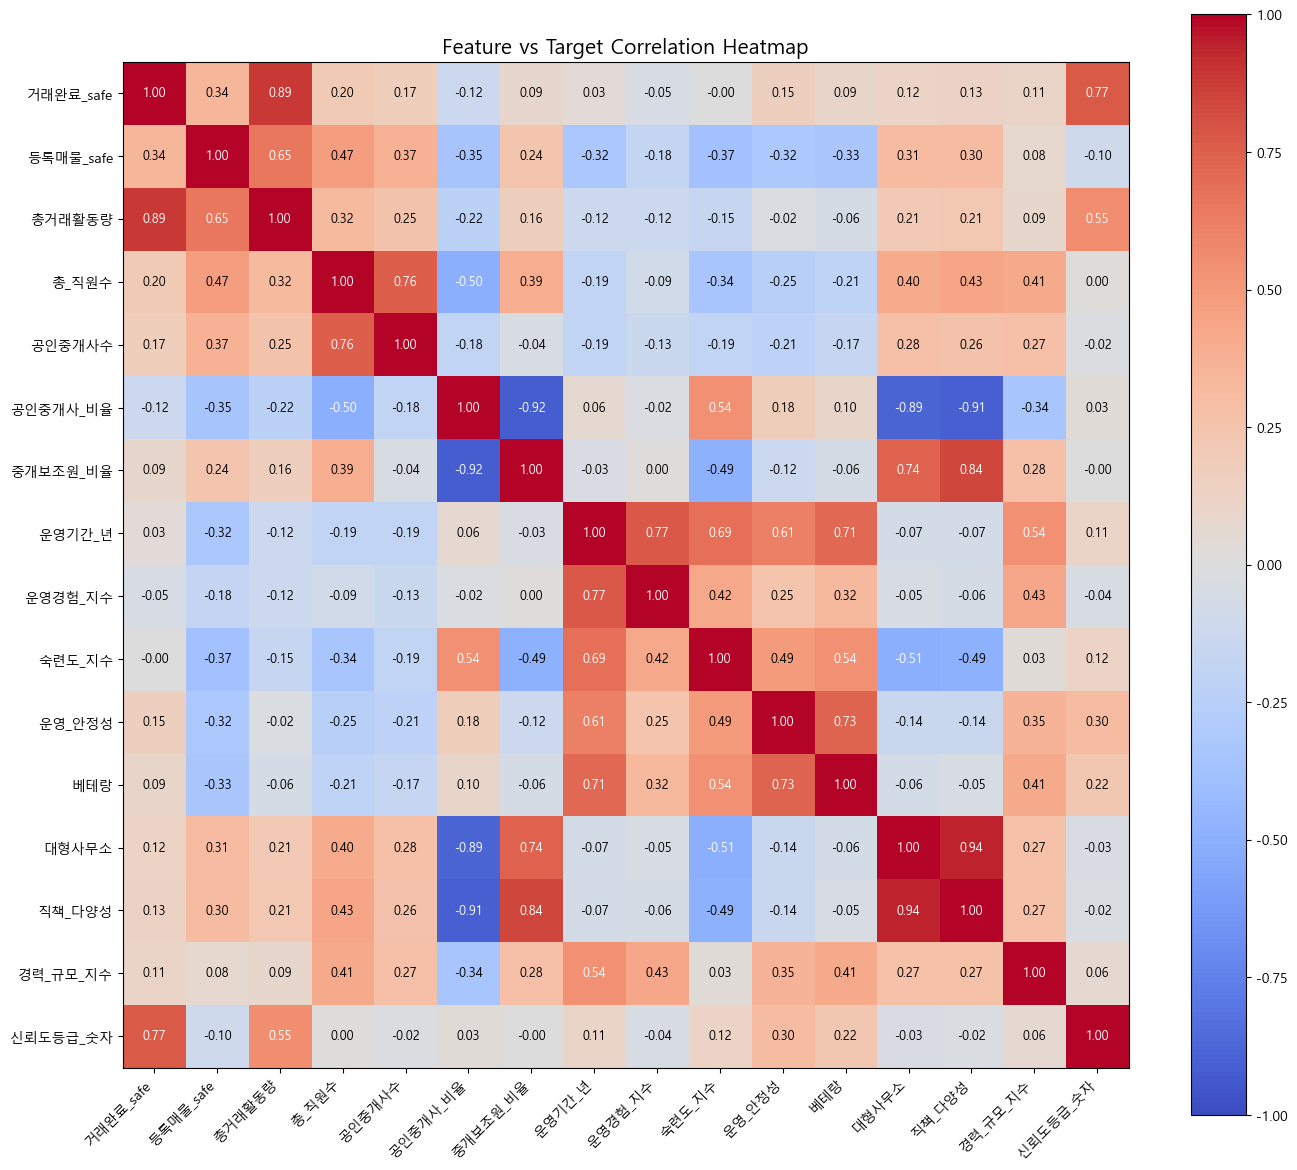

In [25]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns # Try seaborn, fallback to matplotlib if needed, but heatmap is best with seaborn
# If seaborn is not available, we can handle it, but allow try. 
# actually let's stick to matplotlib to be safe as per previous context

def plot_correlation_heatmap():
    # Load Data
    data_path = '../../../../../data/ML/office_features.csv'
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        # Fallback absolute path
        df = pd.read_csv("c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/ML/office_features.csv")
        
    # Define features and target
    features = [
        "거래완료_safe", "등록매물_safe", "총거래활동량",
        "총_직원수", "공인중개사수", "공인중개사_비율", "중개보조원_비율",
        "운영기간_년", "운영경험_지수", "숙련도_지수", "운영_안정성", "베테랑",
        "대형사무소", "직책_다양성", "경력_규모_지수"
    ]
    target = "신뢰도등급_숫자"
    
    # Ensure target exists
    if target not in df.columns and "신뢰도등급" in df.columns:
        df[target] = df["신뢰도등급"].map({'A': 2, 'B': 1, 'C': 0})
        
    # Select columns
    cols_to_analyze = features + [target]
    
    # Check for missing cols
    missing = [c for c in cols_to_analyze if c not in df.columns]
    if missing:
        print(f"Warning: Missing columns in data: {missing}")
        cols_to_analyze = [c for c in cols_to_analyze if c in df.columns]
        
    # Compute Correlation
    corr_matrix = df[cols_to_analyze].corr()
    
    # Plotting
    plt.figure(figsize=(14, 12))
    
    # Using Matplotlib's imshow
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
    plt.colorbar()
    
    # Ticks
    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right', fontsize=10)
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns, fontsize=10)
    plt.title('Feature vs Target Correlation Heatmap', fontsize=15)
    
    # Annotate values
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            text_color = "white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black"
            plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                     ha='center', va='center', color=text_color, fontsize=9)
            
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap()